In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps

from scipy.special import erf

from pathlib import Path

RESULTS_DIR = Path("results")
N_RESULTS_DIR = Path("results_N")
IMAGES_DIR = Path("images")

N_RESULTS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

In [2]:
# ============================================================
# 1. Transfer function
# ============================================================

def transfer(v, theta, sigma):
    """
    Gaussian-closed Heaviside transfer:

        F(v) = 1/2 * [1 + erf((v-theta)/(sqrt(2)*sigma))]
    """
    return 0.5 * (
        1.0
        + erf((v - theta) / (np.sqrt(2.0) * sigma))
    )

In [3]:
# ============================================================
# 2. Parameter construction
# ============================================================

def set_parameters_from_fixed_point(config):
    """
    Given:
        v_star
        alpha
        beta
        theta
        sigma

    compute K and I0 such that:

        1. v_star is a fixed point
        2. beta = K * F'(v_star)

    The configuration is modified in place and returned.
    """

    v_star = config["v_star"]
    alpha = config["alpha"]
    theta = config["theta"]
    sigma = config["sigma"]
    beta = config["beta"]

    if alpha <= 0:
        raise ValueError("alpha must be positive.")
    if sigma <= 0:
        raise ValueError("sigma must be positive.")

    z = (v_star - theta) / (np.sqrt(2.0) * sigma)

    # Transfer at fixed point
    S_star = 0.5 * (1.0 + erf(z))

    # Derivative of transfer at fixed point
    S_prime = (
        np.exp(-z**2)
        / (np.sqrt(2.0 * np.pi) * sigma)
    )

    # Linearized delayed gain
    K = beta / S_prime

    # Fixed-point condition:
    # 0 = -alpha*v_star + K*F_star + I0
    I0 = alpha * v_star - K * S_star

    config["K"] = K
    config["I0"] = I0

    return config

In [4]:
# ============================================================
# 3. Numerical grid / delay utilities
# ============================================================

def align_delay_to_grid(tau, dt):
    """
    Align tau to the nearest integer multiple of dt.
    """
    if tau < 0:
        raise ValueError("tau must be non-negative.")
    if dt <= 0:
        raise ValueError("dt must be positive.")

    delay_steps = int(round(tau / dt))
    return delay_steps * dt

def get_delay_steps(tau, dt):
    """
    Return the integer delay index and verify grid alignment.
    """
    delay_steps = int(round(tau / dt))

    if not np.isclose(delay_steps * dt, tau):
        raise ValueError(
            "Choose dt so that tau/dt is an integer."
        )

    return delay_steps

In [5]:
# ============================================================
# 4. Stability analysis
# ============================================================

def first_hopf_from_beta(alpha, beta):
    """
    First Hopf crossing of

        lambda + alpha - beta*exp(-lambda*tau) = 0.

    A Hopf crossing exists for beta < -alpha.
    """

    if alpha <= 0:
        raise ValueError("alpha must be positive.")

    if beta >= -alpha:
        return np.nan, np.nan

    omega_h = np.sqrt(beta**2 - alpha**2)

    tau_h = (
        np.arccos(alpha / beta)
        / omega_h
    )

    return omega_h, tau_h

def classify_regime(alpha, beta, tau):
    """
    Linear stability classification for

        lambda + alpha - beta*exp(-lambda*tau) = 0.
    """

    if beta > alpha:
        return "positive-real unstable"

    if -alpha <= beta <= alpha:
        return "stable"

    # beta < -alpha
    _, tau_h = first_hopf_from_beta(alpha, beta)

    if tau < tau_h:
        return "stable focus"

    if np.isclose(tau, tau_h):
        return "Hopf boundary"

    return "oscillatory unstable"

In [6]:
# ============================================================
# 5. Mesoscopic model
# ============================================================

def simulate_delayed_meso(config):
    """
    Integrate the mesoscopic DDE:

        dV/dt =
            -alpha*V
            + K*F(V(t-tau))
            + I0

    with fixed Gaussian width sigma.
    """

    alpha = config["alpha"]
    K = config["K"]
    tau = config["tau"]
    I0 = config["I0"]
    theta = config["theta"]
    sigma = config["sigma"]
    dt = config["dt"]
    t_end = config["t_end"]
    history = config["history"]

    if alpha <= 0:
        raise ValueError("alpha must be positive.")
    if sigma <= 0:
        raise ValueError("sigma must be positive.")
    if tau < 0 or dt <= 0 or t_end <= 0:
        raise ValueError(
            "tau must be non-negative; "
            "dt and t_end must be positive."
        )

    delay_steps = get_delay_steps(tau, dt)

    n_steps = int(round(t_end / dt))
    time = np.arange(n_steps + 1) * dt

    state = np.empty(n_steps + 1)
    state[0] = history

    for n in range(n_steps):

        delayed_state = (history if n < delay_steps else state[n - delay_steps])

        derivative = (
            -alpha * state[n]
            + K * transfer(
                delayed_state,
                theta,
                sigma,
            )
            + I0
        )

        state[n + 1] = (
            state[n]
            + dt * derivative
        )

    return time, state

In [7]:
# ============================================================
# 6. Microscopic model
# ============================================================

def simulate_delayed_micro(config):
    """
    Stochastic microscopic model.

    Stores only population-level observables, not the full
    trajectory of every microscopic state.

    Dynamics:

        dx_i =
            [-alpha*x_i
             + K*A(t-tau)
             + I0] dt
            + sqrt(2*alpha)*sigma*dW_i

    with

        A(t) = mean(H(x_i(t) - theta)).
    """

    alpha = config["alpha"]
    K = config["K"]
    tau = config["tau"]
    I0 = config["I0"]
    theta = config["theta"]
    sigma = config["sigma"]
    dt = config["dt"]
    t_end = config["t_end"]
    history = config["history"]

    N = int(config["N"])
    seed = config.get("seed", None)

    delay_steps = get_delay_steps(tau, dt)

    n_steps = int(round(t_end / dt))
    time = np.arange(n_steps + 1) * dt

    rng = np.random.default_rng(seed)

    # --------------------------------------------------------
    # Init microscopic state
    # --------------------------------------------------------

    state = rng.normal(
        loc=history,
        scale=sigma,
        size=N,
    )

    # --------------------------------------------------------
    # Population observables
    # --------------------------------------------------------

    mean_state = np.empty(n_steps + 1)
    population_activity = np.empty(n_steps + 1)

    mean_state[0] = np.mean(state)

    population_activity[0] = np.mean(
        state >= theta
    )

    # --------------------------------------------------------
    # OU noise
    # --------------------------------------------------------

    noise_amplitude = (
        np.sqrt(2.0 * alpha) * sigma
    )

    # --------------------------------------------------------
    # Simulation
    # --------------------------------------------------------

    for n in range(n_steps):

        if n < delay_steps:
            activity_tau = population_activity[0]
        else:
            activity_tau = population_activity[n - delay_steps]

        drift = (
            -alpha * state
            + K * activity_tau
            + I0
        )

        noise = (
            noise_amplitude
            * np.sqrt(dt)
            * rng.standard_normal(N)
        )

        state += dt * drift + noise

        population_activity[n + 1] = np.mean(
            state >= theta
        )

        mean_state[n + 1] = np.mean(state)

    return (
        time,
        mean_state,
        population_activity,
    )

In [8]:
# ============================================================
# 7. Example: construct a Hopf configuration
# ============================================================

v_star = 1.0

config = {
    "N": 10000,
    "v_star": v_star,
    "alpha": 0.5,
    "K": np.nan,
    "I0": np.nan,
    "theta": v_star+1.0,
    "sigma": 1.0,
    "dt": 0.001,
    "t_end": 100.0,
    "tau": np.nan,
    "history": v_star+0.1,
    "beta": -2.0,
    "seed": 1234,
}

# Set K and I0 from beta and desired fixed point
config = set_parameters_from_fixed_point(config)

# Analytical Hopf point
omega_h, tau_h = first_hopf_from_beta(
    config["alpha"],
    config["beta"],
)

# Numerically realizable delay
config["tau"] = align_delay_to_grid(
    tau_h,
    config["dt"],
)

print(f"K                = {config['K']:.8f}")
print(f"I0               = {config['I0']:.8f}")
print(f"beta             = {config['beta']:.8f}")
print(f"omega_H          = {omega_h:.8f}")
print(f"tau_H analytical = {tau_h:.8f}")
print(f"tau simulated    = {config['tau']:.8f}")
print(
    f"tau error        = "
    f"{config['tau'] - tau_h:+.3e}"
)

print(
    "linear regime    =",
    classify_regime(
        config["alpha"],
        config["beta"],
        config["tau"],
    ),
)

K                = -8.26546271
I0               = 1.81135908
beta             = -2.00000000
omega_H          = 1.93649167
tau_H analytical = 0.94163926
tau simulated    = 0.94200000
tau error        = +3.607e-04
linear regime    = oscillatory unstable


In [9]:
def compute_case(config, case):

    cfg = config.copy()

    cfg["beta"] = case["beta"]
    cfg["tau"] = align_delay_to_grid(
        case["tau"],
        cfg["dt"],
    )

    cfg = set_parameters_from_fixed_point(cfg)

    # Use exact fixed-point history at bifurcation boundaries
    if case["label"] in [
        "Saddle-node boundary",
    ]:
        cfg["history"] = cfg["v_star"]

    # Simulation duration
    if case["beta"] < 0:
        cfg["t_end"] = 100.0
    else:
        cfg["t_end"] = 50.0

    # Run mesoscopic
    t_meso, x_meso = simulate_delayed_meso(cfg)

    # Run microscopic
    (
        t_micro,
        mean_micro,
        population_activity,
    ) = simulate_delayed_micro(cfg)

    return {
        "case": case,
        "config": cfg,
        "t_meso": t_meso,
        "x_meso": x_meso,
        "t_micro": t_micro,
        "mean_micro": mean_micro,
        "population_activity": population_activity,
    }

In [10]:
cases = [
    # ODE-like regimes
    {
        "label": "Stable node",
        "beta": 0.0,
        "tau": 0.0,
    },
    {
        "label": "Saddle-node boundary",
        "beta": config["alpha"],
        "tau": 0.0,
    },
    {
        "label": "Unstable node",
        "beta": 0.6,
        "tau": 0.0,
    },

    # Delayed regimes
    {
        "label": "Below Hopf",
        "beta": -2.0,
        "tau": 0.8 * tau_h,
    },
    {
        "label": "At Hopf",
        "beta": -2.0,
        "tau": tau_h,
    },
    {
        "label": "Above Hopf",
        "beta": -2.0,
        "tau": 1.2 * tau_h,
    },
]

In [11]:
def load_case(filename):
    """
    Load one stored simulation case.
    """

    path = RESULTS_DIR / filename

    data = np.load(
        path,
        allow_pickle=False,
    )

    return data

/tmp/ipykernel_5211/2709234031.py:116: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


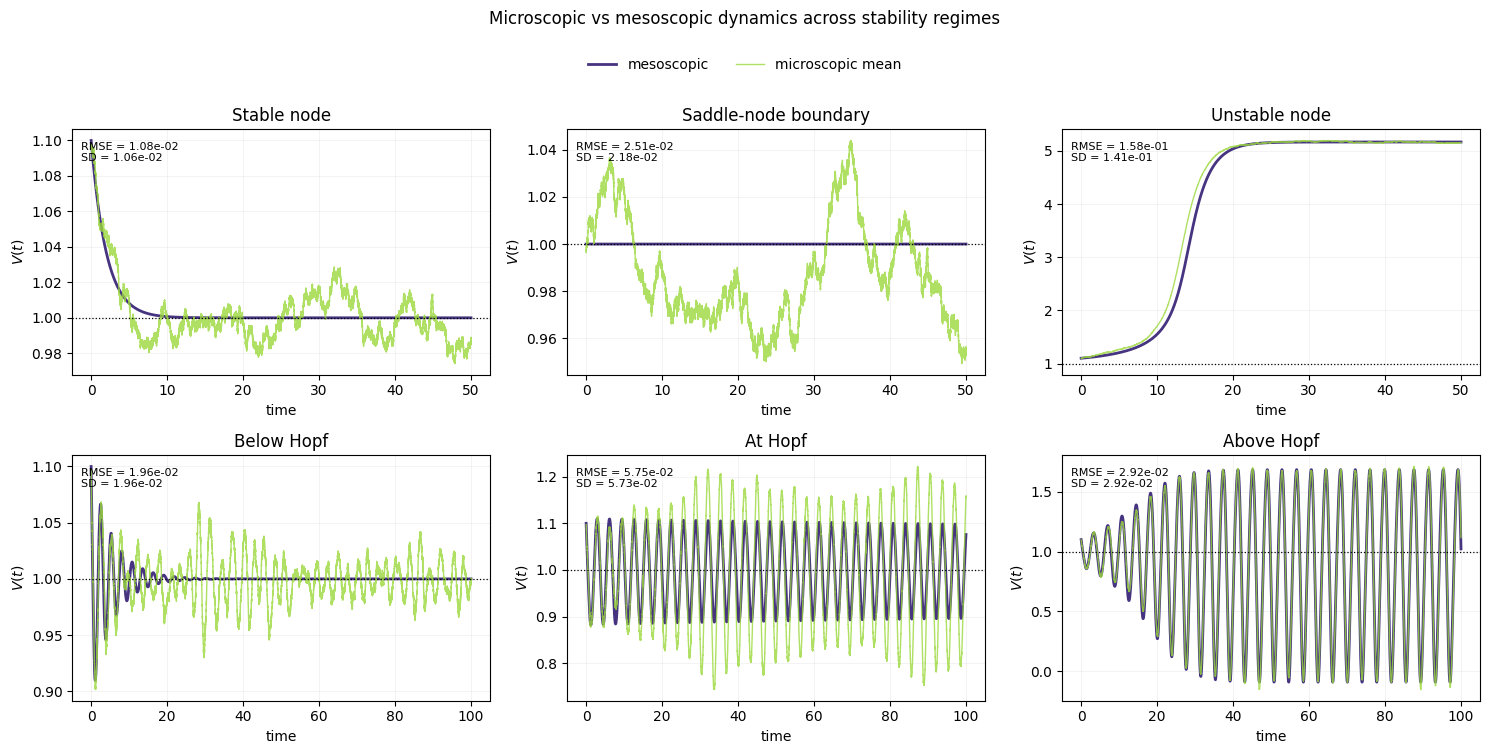

In [13]:
cmap = colormaps["viridis"]

COLOR_MESO = cmap(0.15)
COLOR_MICRO = cmap(0.85)


file_map = {
    "Stable node": "stable_node.npz",
    "Saddle-node boundary": "saddlenode_boundary.npz",
    "Unstable node": "unstable_node.npz",
    "Below Hopf": "below_hopf.npz",
    "At Hopf": "at_hopf.npz",
    "Above Hopf": "above_hopf.npz",
}


fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 7),
    sharex=False,
    sharey=False,
    constrained_layout=True,
)


for ax, case in zip(axes.flat, cases):

    data = load_case(
        file_map[case["label"]]
    )

    t_meso = data["t_meso"]
    x_meso = data["x_meso"]

    t_micro = data["t_micro"]
    mean_micro = data["mean_micro"]

    error = mean_micro - x_meso

    rmse = np.sqrt(np.mean(error**2))
    std = np.std(error)

    ax.plot(
        t_meso,
        x_meso,
        color=COLOR_MESO,
        linewidth=2.0,
        label="mesoscopic",
    )

    ax.plot(
        t_micro,
        mean_micro,
        color=COLOR_MICRO,
        linewidth=1.0,
        alpha=0.8,
        label="microscopic mean",
    )

    ax.axhline(
        config["v_star"],
        color="black",
        linestyle=":",
        linewidth=0.9,
    )

    ax.text(
        0.02,
        0.95,
        f"RMSE = {rmse:.2e}\nSD = {std:.2e}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=8,
    )

    ax.set_title(case["label"])
    ax.set_xlabel("time")
    ax.set_ylabel(r"$V(t)$")

    ax.grid(
        alpha=0.15,
        linewidth=0.7,
    )

    # --------------------------------------------------------
    # Normal Matplotlib autoscaling
    # --------------------------------------------------------

    ax.relim()
    ax.autoscale_view()

# ------------------------------------------------------------
# Common legend
# ------------------------------------------------------------

handles, labels = (
    axes[0, 0].get_legend_handles_labels()
)

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    "Microscopic vs mesoscopic dynamics across stability regimes",
    y=1.07,
)

fig.tight_layout()
#plt.savefig(str(IMAGES_DIR) + "/lin_stab_micro-meso_comparison.jpg", dpi=300,bbox_inches="tight",)
plt.show()

In [14]:
def compute_N_case(config, N, seed=1234):

    cfg = config.copy()

    cfg["N"] = N
    cfg["seed"] = seed

    # Everything else stays identical
    t_meso, x_meso = simulate_delayed_meso(cfg)

    (
        t_micro,
        mean_micro,
        population_activity,
    ) = simulate_delayed_micro(cfg)

    return {
        "N": N,
        "seed": seed,

        "t_meso": t_meso,
        "x_meso": x_meso,

        "t_micro": t_micro,
        "mean_micro": mean_micro,
        "population_activity": population_activity,
    }

In [15]:
def save_N_case(result, directory=N_RESULTS_DIR):

    N = result["N"]

    path = directory / f"N_{N}.npz"

    np.savez_compressed(
        path,

        N=result["N"],
        seed=result["seed"],

        t_meso=result["t_meso"],
        x_meso=result["x_meso"],

        t_micro=result["t_micro"],
        mean_micro=result["mean_micro"],

        population_activity=result[
            "population_activity"
        ],
    )

    print(f"Saved: {path}")

In [16]:
N_VALUES = [100, 500, 1000, 5000, 10000]

N_CASE = "at_hopf"   # or "below_hopf", "above_hopf", etc.
SEED = 1234

In [17]:
def load_N_case(
    N,
    directory=N_RESULTS_DIR,
):

    path = directory / f"N_{N}.npz"

    return np.load(
        path,
        allow_pickle=False,
    )

In [19]:
def compute_N_metrics(data):

    x_meso = data["x_meso"]
    mean_micro = data["mean_micro"]

    error = mean_micro - x_meso

    rmse = np.sqrt(
        np.mean(error**2)
    )

    std = np.std(error)

    return {
        "N": int(data["N"]),
        "RMSE": rmse,
        "SD": std,
    }

In [20]:
metrics = []

for N in N_VALUES:

    data = load_N_case(N)

    metrics.append(
        compute_N_metrics(data)
    )

for m in metrics:

    print(
        f"N = {m['N']:5d} | "
        f"RMSE = {m['RMSE']:.6e} | "
        f"SD = {m['SD']:.6e}"
    )

N =   100 | RMSE = 3.116383e-01 | SD = 3.094402e-01
N =   500 | RMSE = 1.850911e-01 | SD = 1.840360e-01
N =  1000 | RMSE = 1.187068e-01 | SD = 1.185713e-01
N =  5000 | RMSE = 5.917342e-02 | SD = 5.916580e-02
N = 10000 | RMSE = 5.752035e-02 | SD = 5.728162e-02


In [21]:
COLORS_N = [
    "#2563EB",  # blue
    "#F97316",  # orange
    "#16A34A",  # green
    "#9333EA",  # purple
    "#DC2626",  # red
]

In [22]:
def plot_N_trajectories(
    N_values,
    results_dir,
    v_star,
    colors=COLORS_N,
    save=False,
):

    fig, axes = plt.subplots(
        2,
        3,
        figsize=(15, 8),
        constrained_layout=True,
    )

    axes = axes.flat

    # ========================================================
    # Load data and compute metrics once
    # ========================================================

    data = {}
    metrics_by_N = {}

    for N in N_values:

        data[N] = load_N_case(
            N,
            directory=results_dir,
        )

        metrics_by_N[N] = compute_N_metrics(
            data[N]
        )

    # ========================================================
    # Panel 1: all N together
    # ========================================================

    ax = axes[0]

    for N, color in zip(N_values, colors):

        ax.plot(
            data[N]["t_micro"],
            data[N]["mean_micro"],
            color=color,
            linewidth=1.5,
            alpha=0.85,
            label=fr"$N={N}$",
            zorder=1,
        )

    ax.plot(
        data[N_values[0]]["t_meso"],
        data[N_values[0]]["x_meso"],
        color="black",
        linewidth=2.5,
        label="mesoscopic",
        zorder=2,
    )

    ax.axhline(
        v_star,
        color="black",
        linestyle=":",
        linewidth=0.9,
        alpha=0.5,
    )

    ax.text(
        0.02,
        0.98,
        "\n".join(
            [
                (
                    f"RMSE={metrics_by_N[N]['RMSE']:.1e}"
                )
                for N in N_values
            ]
        ),
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=8,
        bbox=dict(
            facecolor="white",
            alpha=0.7,
            edgecolor="none",
        ),
    )

    ax.set_title("All populations")
    ax.set_xlabel("time")
    ax.set_ylabel(r"$V(t)$")

    ax.grid(
        alpha=0.15,
        linewidth=0.7,
    )

    ax.legend(
        frameon=False,
        ncol=2,
    )

    # ========================================================
    # Panels 2–6: individual N comparisons
    # ========================================================

    for ax, N, color in zip(
        axes[1:],
        N_values,
        colors,
    ):

        metric = metrics_by_N[N]

        ax.plot(
            data[N]["t_meso"],
            data[N]["x_meso"],
            color="black",
            linewidth=2.5,
            label="mesoscopic",
            zorder=2,
        )

        ax.plot(
            data[N]["t_micro"],
            data[N]["mean_micro"],
            color=color,
            linewidth=1.5,
            alpha=0.85,
            label=fr"$N={N}$",
            zorder=1,
        )

        ax.axhline(
            v_star,
            color="black",
            linestyle=":",
            linewidth=0.9,
            alpha=0.5,
        )

        ax.text(
            0.02,
            0.98,
            (
                f"RMSE = {metric['RMSE']:.2e}\n"
                f"SD = {metric['SD']:.2e}"
            ),
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=9,
            bbox=dict(
                facecolor="white",
                alpha=0.8,
                edgecolor="none",
            ),
        )

        ax.set_title(fr"$N={N}$")
        ax.set_xlabel("time")
        ax.set_ylabel(r"$V(t)$")

        ax.grid(
            alpha=0.15,
            linewidth=0.7,
        )

        ax.legend(
            frameon=False,
        )

    fig.suptitle(
        "Micro–meso comparison across population size",
        y=1.02,
    )

    if save:
        fig.savefig(
            str(IMAGES_DIR) + 
            "/micro-meso_comparison_across_pop_size.jpg",
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

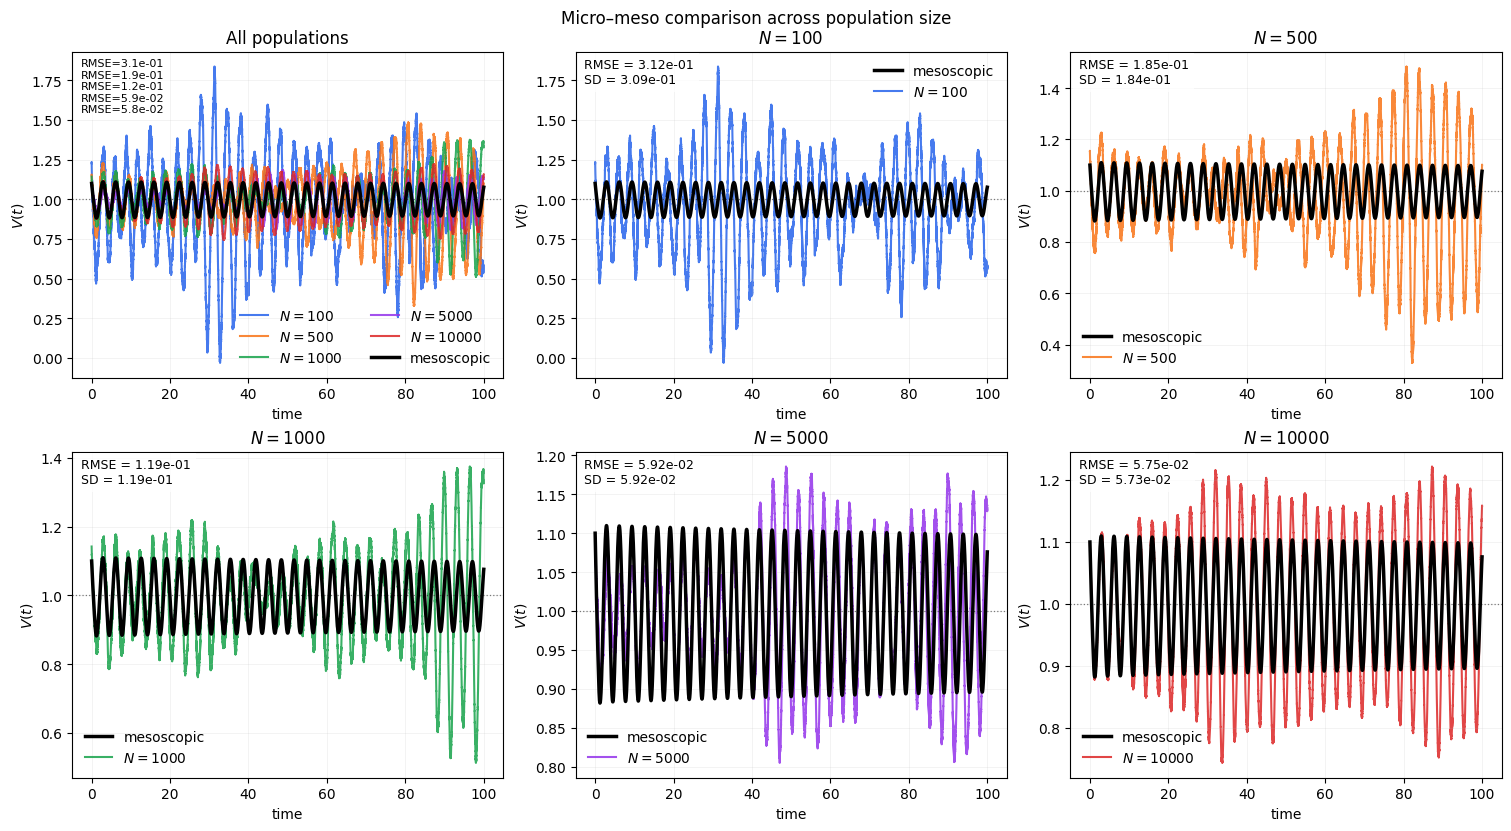

In [23]:
plot_N_trajectories(
    N_VALUES,
    N_RESULTS_DIR,
    config["v_star"],
    colors=COLORS_N,
    save='False'
)

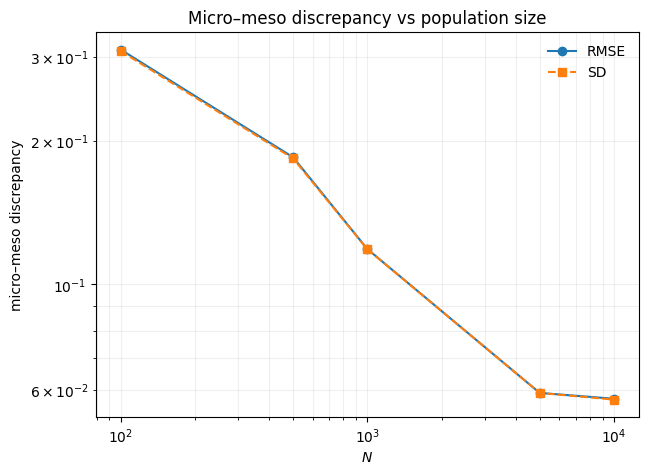

In [24]:
N_array = np.array(
    [m["N"] for m in metrics]
)

rmse_array = np.array(
    [m["RMSE"] for m in metrics]
)

sd_array = np.array(
    [m["SD"] for m in metrics]
)

fig, ax = plt.subplots(
    figsize=(7, 5),
)

ax.loglog(
    N_array,
    rmse_array,
    "o-",
    linewidth=1.5,
    label="RMSE",
)

ax.loglog(
    N_array,
    sd_array,
    "s--",
    linewidth=1.5,
    label="SD",
)

ax.set_xlabel(r"$N$")
ax.set_ylabel("micro–meso discrepancy")

ax.set_title(
    "Micro–meso discrepancy vs population size"
)

ax.grid(
    alpha=0.2,
    which="both",
)

ax.legend(frameon=False)

plt.show()

In [25]:
slope, intercept = np.polyfit(
    np.log(N_array),
    np.log(rmse_array),
    1,
)

print(
    f"RMSE scaling exponent = {slope:.3f}"
)

RMSE scaling exponent = -0.394
